In [26]:
import pickle
import torch

import gradoptics as optics
from gradoptics.integrator import HierarchicalSamplingIntegrator
from ml.siren import Siren

import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

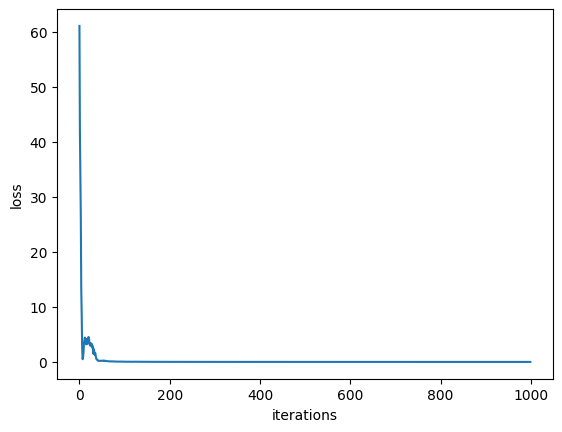

In [27]:
import pandas as pd

loss = pd.read_csv('loss_pixel_size_same.csv')
plt.plot(loss[:1000],'-')
plt.xlabel('iterations')
plt.ylabel('loss')
plt.show()

## Same scene setup as in training notebook

In [28]:
light_source = optics.LightSourceFromDistribution(optics.AtomCloud(phi=0.1, w0=0.005, k_fringe=0,
                                                                   position=[0., 0., 0.]))

In [29]:
device = 'cuda'

in_features = 3
hidden_features = 256
hidden_layers = 3
out_features = 1

model = Siren(in_features, hidden_features, hidden_layers, out_features,
              outermost_linear=True, outermost_linear_activation=nn.ReLU()).double().to(device)

In [30]:
import torch

# Clear GPU memory (for PyTorch)
torch.cuda.empty_cache()

## Set up grid to sample
1/sqrt(2) is the edge of the cube that falls within a sphere of radius 1 (to avoid corner effects)

In [31]:
n_side = 100
bound = 1/np.sqrt(3.)
grid = torch.cartesian_prod(torch.linspace(-bound, bound, n_side),
                            torch.linspace(-bound, bound, n_side),
                            torch.linspace(-bound, bound, n_side)).cuda().double()

## Load model and evaluate densities

In [32]:
f_pattern = 'model_*_NW_MOT_all_cameras_long.pt'

In [33]:
from glob import glob
n_checkpoints = len(glob(f_pattern))

In [34]:
last = (n_checkpoints-1)*500
print(last)

49500


In [35]:
with torch.no_grad():
    fname = f_pattern.replace("*", "{last}").format(last=last)
    model.load_state_dict(torch.load(fname))

In [36]:
batch_size = 100**3
with torch.no_grad():
    fname = f_pattern.replace("*", "{last}").format(last=last)
    model.load_state_dict(torch.load(fname))
    densities = []
    grid_batches = grid.split(batch_size)
    for grid_batch in tqdm(grid_batches):
        densities.append(model(grid_batch)[0].cpu())
    densities = torch.cat(densities).reshape((n_side, n_side, n_side))

100%|██████████████████████████████████████████████████████| 1/1 [00:00<00:00, 12.32it/s]


In [37]:
rad=0.03
n_side = 100
real_grid = torch.cartesian_prod(torch.linspace(-bound*rad, bound*rad, n_side),
                            torch.linspace(-bound*rad, bound*rad, n_side),
                            torch.linspace(-bound*rad, bound*rad, n_side)).cuda().double()
pdf_vals = light_source.pdf(real_grid).reshape((n_side, n_side, n_side)).cpu()

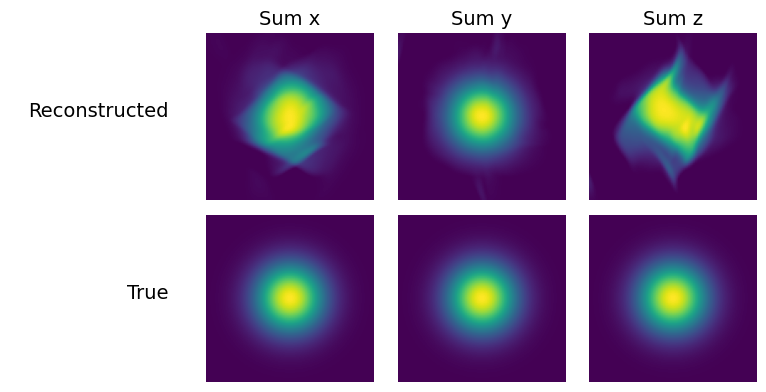

In [38]:
%matplotlib inline
fig, ax = plt.subplots(2, 4, figsize=(8,4))

ax[0, 0].text(0.9, 0.5, "Reconstructed", ha='right', fontsize=14)
ax[0, 0].axis('off')

ax[1, 0].text(0.9, 0.5, "True", ha='right', fontsize=14)
ax[1, 0].axis('off')

ax[0, 1].imshow(densities.sum(dim=0).T, origin="lower")
ax[0, 1].set_title('Sum x', fontsize=14)
ax[0, 1].axis('off')

ax[0, 2].imshow(densities.sum(dim=1).T, origin="lower")
ax[0, 2].set_title('Sum y', fontsize=14)
ax[0, 2].axis('off')

ax[0, 3].imshow(densities.sum(dim=2).T, origin="lower")
ax[0, 3].set_title('Sum z', fontsize=14)
ax[0, 3].axis('off')

ax[1, 1].imshow(pdf_vals.sum(dim=0).T, origin="lower")
ax[1, 1].axis('off')

ax[1, 2].imshow(pdf_vals.sum(dim=1).T, origin="lower")
ax[1, 2].axis('off')

ax[1, 3].imshow(pdf_vals.sum(dim=2).T, origin="lower")
ax[1, 3].axis('off')
plt.tight_layout()
save_name = fname.replace('.pt', '.png').replace('model', 'marginal')
plt.savefig(save_name, dpi=300)

mrcfile lets you load a 3D representation with, e.g., ChimeraX

In [39]:
import mrcfile
filename = fname.replace('.pt', '.mrc').replace('model', 'test_mrc_rand')
with mrcfile.new(filename, overwrite=True) as mrc:
    mrc.set_data(densities.float().cpu().detach().numpy())
    mrc.voxel_size = 2*rad*bound/grid.shape[0]

We can make a training animation

In [16]:
all_densities = []
with torch.no_grad():
    for n_iter in tqdm(np.arange(0, n_checkpoints*500, 500)):
        model.load_state_dict(torch.load(f_pattern.replace("*", "{n_iter}").format(n_iter=n_iter)))
        densities = model(grid)[0].reshape((n_side, n_side, n_side)).cpu()
        all_densities.append(densities.clone())

100%|██████████████████████████████████████████████████| 100/100 [00:09<00:00, 10.91it/s]


In [ ]:
%matplotlib notebook
from celluloid import Camera
fig, ax = plt.subplots(2, 4, figsize=(8,4))
camera = Camera(fig)

for i in range(len(all_densities)):
    ax[0, 0].text(0.9, 0.5, "Reconstructed", ha='right', fontsize=14)
    ax[0, 0].axis('off')

    ax[1, 0].text(0.9, 0.5, "True", ha='right', fontsize=14)
    ax[1, 0].axis('off')

    ax[0, 1].imshow(all_densities[i].sum(dim=0).T, origin="lower")
    ax[0, 1].set_title('Sum x', fontsize=14)
    ax[0, 1].axis('off')

    ax[0, 2].imshow(all_densities[i].detach().sum(dim=1).T, origin="lower")
    ax[0, 2].set_title('Sum y', fontsize=14)
    ax[0, 2].axis('off')

    ax[0, 3].imshow(all_densities[i].sum(dim=2).T, origin="lower")
    ax[0, 3].set_title('Sum z', fontsize=14)
    ax[0, 3].axis('off')
    

    ax[1, 1].imshow(pdf_vals.sum(dim=0).T, origin="lower")
    ax[1, 1].axis('off')

    ax[1, 2].imshow(pdf_vals.sum(dim=1).T, origin="lower")
    ax[1, 2].axis('off')

    ax[1, 3].imshow(pdf_vals.sum(dim=2).T, origin="lower")
    ax[1, 3].axis('off')

    plt.tight_layout()
    camera.snap()

animation = camera.animate()
save_name = fname.replace('.pt', '.gif').replace('model', 'training_rand')
animation.save(save_name)

#from IPython.display import HTML
#HTML(animation.to_html5_video())

Or we can render images

In [8]:
scene_objects = pickle.load(open("NW_mot_scene_components.pkl", "rb"))
data_intensities_all = pickle.load(open("NW_mot_images.pkl", "rb"))

In [9]:
targets = [];
for img in data_intensities_all:
    targets.append(img.flatten().cuda())

In [10]:
sel_mask = []
for img in targets:
    sel_mask.append(torch.ones(img.shape, dtype=torch.bool))

In [11]:
rad = 0.03
obj_pos = (0, 0, 0)

light_source = optics.LightSourceFromNeuralNet(model, optics.BoundingSphere(radii=rad, 
                                                                     xc=obj_pos[0], yc=obj_pos[1], zc=obj_pos[2]),
                                        rad=rad, x_pos=obj_pos[0], y_pos=obj_pos[1], z_pos=obj_pos[2])
scene_train = optics.Scene(light_source)

for obj in scene_objects:
    scene_train.add_object(obj)

In [12]:
sensor_list = [obj for obj in scene_train.objects if type(obj) == optics.Sensor]
lens_list = [obj for obj in scene_train.objects if type(obj) == optics.PerfectLens]

In [13]:
from gradoptics.integrator import HierarchicalSamplingIntegrator
integrator = HierarchicalSamplingIntegrator(64, 64, stratify = False)

In [14]:
torch.cuda.empty_cache()

In [16]:
pixel_batch = 200000//40
camera_intensities_all = []
with torch.no_grad():
    for i,obj in enumerate(scene_objects):
        if type(obj) == optics.Sensor:
            sensor = scene_objects[i]
            lens = scene_objects[i+1]
            
            # Define pixel indices
            idxs = torch.cartesian_prod(torch.arange(sensor.resolution[0]//2, -sensor.resolution[0]//2, -1), 
                                torch.arange(sensor.resolution[1]//2, -sensor.resolution[1]//2, -1))
        
            pix_x, pix_y = idxs.T
        
            # Batch over them for rendering -- I used a large GPU
            batch_pix_x = pix_x.split(pixel_batch)
            batch_pix_y = pix_y.split(pixel_batch)
        
            intensities_all = []
            
            device = 'cuda'
            lens_pos = scene_objects[i+1].transform.transform[:-1, -1].to(device)       
            
            for j in tqdm(range(len(batch_pix_x))):
                nb_pixels = len(batch_pix_x[j])
                            
                origins = torch.zeros((nb_pixels,3),device = device,dtype = torch.float64)
                origins[:,0] = (batch_pix_x[j].to(device))* sensor.pixel_size[0]
                origins[:,1] = (batch_pix_y[j].to(device))* sensor.pixel_size[1]
                origins = sensor.c2w.apply_transform_(origins.reshape(-1, 3)).reshape((nb_pixels, 3))
                pA = 1 / (sensor.resolution[0] * sensor.pixel_size[0] * sensor.resolution[1] * sensor.pixel_size[1])         
                
                directions = lens_pos - origins
                directions = directions/torch.norm(directions, dim=1, keepdim=True)  
               
                outgoing_rays = optics.Rays(origins, directions, device='cuda')
                intensities_all.append(optics.backward_ray_tracing(outgoing_rays,scene_train, scene_train.light_source,integrator, max_iterations=6))
        
            camera_intensities = torch.cat(intensities_all).reshape(sensor.resolution).cpu()
            camera_intensities_all.append(camera_intensities.clone())

100%|██████████████████████████████████████████████████| 308/308 [00:28<00:00, 10.89it/s]


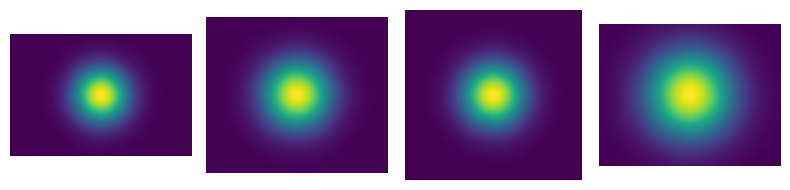

In [43]:

%matplotlib inline
fig, ax = plt.subplots(1,4, figsize=(8, 2))
for i in range(len(camera_intensities_all)):
    im = ax[i].imshow(camera_intensities_all[i].cpu().T)
    #ax[i//4, i%4].set_title(f"{camera_params[i]['name']}")
    ax[i].axis('off')
plt.tight_layout()